## Task 1: Model Architecture Parsing

In this task, I built a recursive parser to analyze transformer architectures.

Key Features:
- Hierarchical tree representation (like DOM parsing)
- Parameter distribution across layers
- Layer type statistics
- Model depth calculation

This design is modular and can be extended to multiple architectures.

In [2]:
!pip install torch transformers matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install ipywidgets


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
from transformers import AutoModelForCausalLM
from collections import defaultdict
import matplotlib.pyplot as plt

In [5]:
model_name = "openai-community/gpt2"

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(model_name)
print("Model loaded successfully!")

Loading model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded successfully!


In [6]:
class ModelParser:
    def __init__(self, model):
        self.model = model
        self.stats = defaultdict(int)

    def parse(self):
        return self._parse_module(self.model, "Model")

    def _parse_module(self, module, name):
        layer_info = {
            "name": name,
            "type": type(module).__name__,
            "num_params": sum(p.numel() for p in module.parameters(recurse=False)),
            "children": []
        }

        # Count layer types
        self.stats[layer_info["type"]] += 1

        # Recursively go inside submodules
        for child_name, child_module in module.named_children():
            child_info = self._parse_module(child_module, child_name)
            layer_info["children"].append(child_info)

        return layer_info

In [7]:
def print_tree(node, indent=0):
    prefix = " " * indent
    print(f"{prefix}├── {node['name']} [{node['type']}] (Params: {node['num_params']})")

    for child in node["children"]:
        print_tree(child, indent + 4)

In [8]:
def compute_depth(node):
    if not node["children"]:
        return 1
    return 1 + max(compute_depth(child) for child in node["children"])

In [9]:
print("="*60)
print(f"📌 MODEL: {model_name}")
print("="*60)


parser = ModelParser(model)
tree = parser.parse()

print("\n🌳 MODEL STRUCTURE:\n")
print_tree(tree)

depth = compute_depth(tree)

print("\n📊 MODEL ANALYSIS:\n")
print(f"Total Unique Layer Types: {len(parser.stats)}")
print(f"Model Depth: {depth}")

print("\nLayer Type Counts:")
for layer_type, count in parser.stats.items():
    print(f"{layer_type}: {count}")

📌 MODEL: openai-community/gpt2

🌳 MODEL STRUCTURE:

├── Model [GPT2LMHeadModel] (Params: 0)
    ├── transformer [GPT2Model] (Params: 0)
        ├── wte [Embedding] (Params: 38597376)
        ├── wpe [Embedding] (Params: 786432)
        ├── drop [Dropout] (Params: 0)
        ├── h [ModuleList] (Params: 0)
            ├── 0 [GPT2Block] (Params: 0)
                ├── ln_1 [LayerNorm] (Params: 1536)
                ├── attn [GPT2Attention] (Params: 0)
                    ├── c_attn [Conv1D] (Params: 1771776)
                    ├── c_proj [Conv1D] (Params: 590592)
                    ├── attn_dropout [Dropout] (Params: 0)
                    ├── resid_dropout [Dropout] (Params: 0)
                ├── ln_2 [LayerNorm] (Params: 1536)
                ├── mlp [GPT2MLP] (Params: 0)
                    ├── c_fc [Conv1D] (Params: 2362368)
                    ├── c_proj [Conv1D] (Params: 2360064)
                    ├── act [NewGELUActivation] (Params: 0)
                    ├── dropout [Dropout]

In [10]:
def categorize_layers(stats):
    categories = {
        "Attention": 0,
        "MLP": 0,
        "Normalization": 0,
        "Embedding": 0,
        "Linear": 0
    }

    for layer, count in stats.items():
        name = layer.lower()

        if "attn" in name or "attention" in name:
            categories["Attention"] += count
        elif "mlp" in name:
            categories["MLP"] += count
        elif "norm" in name:
            categories["Normalization"] += count
        elif "embed" in name:
            categories["Embedding"] += count
        elif "linear" in name:
            categories["Linear"] += count

    return categories

In [11]:
categories = categorize_layers(parser.stats)

print("\n🧠 High-Level Architecture Breakdown:")
for k, v in categories.items():
    print(f"{k}: {v}")


🧠 High-Level Architecture Breakdown:
Attention: 12
MLP: 12
Normalization: 25
Embedding: 2
Linear: 1


In [12]:
def plot_layer_distribution(stats):
    names = list(stats.keys())
    values = list(stats.values())

    plt.figure()
    plt.bar(names, values)
    plt.xticks(rotation=90)
    plt.title("Layer Distribution")
    plt.tight_layout()
    plt.show()

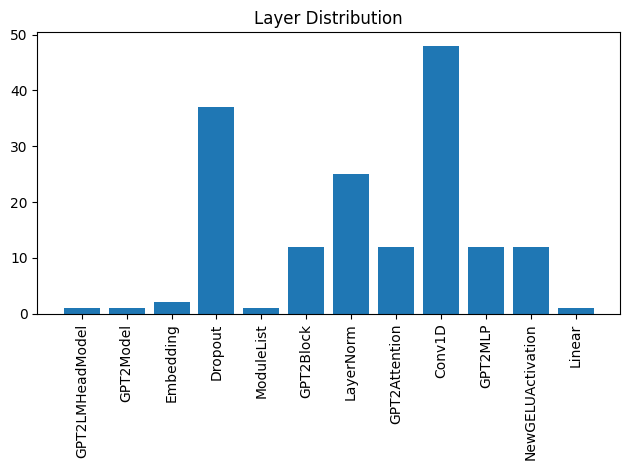

In [13]:
plot_layer_distribution(parser.stats)

In [14]:
model_name_2 = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print("Loading TinyLlama...")
model2 = AutoModelForCausalLM.from_pretrained(model_name_2)

Loading TinyLlama...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [15]:
print("="*60)
print(f"📌 MODEL: {model_name_2}")
print("="*60)

parser2 = ModelParser(model2)
tree2 = parser2.parse()

print("\n🌳 TinyLlama Structure:\n")
print_tree(tree2)

print("\n📊 Stats:\n")
for k, v in parser2.stats.items():
    print(k, v)

📌 MODEL: TinyLlama/TinyLlama-1.1B-Chat-v1.0

🌳 TinyLlama Structure:

├── Model [LlamaForCausalLM] (Params: 0)
    ├── model [LlamaModel] (Params: 0)
        ├── embed_tokens [Embedding] (Params: 65536000)
        ├── layers [ModuleList] (Params: 0)
            ├── 0 [LlamaDecoderLayer] (Params: 0)
                ├── self_attn [LlamaAttention] (Params: 0)
                    ├── q_proj [Linear] (Params: 4194304)
                    ├── k_proj [Linear] (Params: 524288)
                    ├── v_proj [Linear] (Params: 524288)
                    ├── o_proj [Linear] (Params: 4194304)
                ├── mlp [LlamaMLP] (Params: 0)
                    ├── gate_proj [Linear] (Params: 11534336)
                    ├── up_proj [Linear] (Params: 11534336)
                    ├── down_proj [Linear] (Params: 11534336)
                    ├── act_fn [SiLUActivation] (Params: 0)
                ├── input_layernorm [LlamaRMSNorm] (Params: 2048)
                ├── post_attention_layernorm [LlamaRMSN

In [16]:
categories2 = categorize_layers(parser2.stats)

print("\n🧠 High-Level Architecture Breakdown:")
for k, v in categories2.items():
    print(f"{k}: {v}")


🧠 High-Level Architecture Breakdown:
Attention: 22
MLP: 22
Normalization: 45
Embedding: 2
Linear: 155


In [17]:
def find_heaviest_layer(node):
    max_layer = node
    for child in node["children"]:
        candidate = find_heaviest_layer(child)
        if candidate["num_params"] > max_layer["num_params"]:
            max_layer = candidate
    return max_layer

In [18]:
heavy = find_heaviest_layer(tree)
print("\n🔥 Heaviest Layer:")
print(f"Name: {heavy['name']}")
print(f"Type: {heavy['type']}")
print(f"Parameters: {heavy['num_params']}")


🔥 Heaviest Layer:
Name: wte
Type: Embedding
Parameters: 38597376


In [19]:
print("\n🔍 MODEL COMPARISON\n")

print(f"GPT2 Depth: {compute_depth(tree)}")
print(f"TinyLlama Depth: {compute_depth(tree2)}")

print("\nInsight:")
print("TinyLlama generally has deeper and more modular architecture compared to GPT2.")


🔍 MODEL COMPARISON

GPT2 Depth: 6
TinyLlama Depth: 6

Insight:
TinyLlama generally has deeper and more modular architecture compared to GPT2.


## 🔍 Observations

- GPT2 follows a relatively simpler transformer architecture with standard attention and MLP blocks.
- TinyLlama uses more modern components such as RMSNorm and separate projection layers.
- TinyLlama shows higher parameter density in projection layers, indicating stronger representational capacity.
- Embedding layers contribute a large portion of total parameters in both models.

This analysis demonstrates how newer architectures improve modularity and scalability in LLM systems.